# 💻 Laptop Price Prediction using Machine Learning

### Final Project

---

### 📌 Deskripsi

Proyek ini bertujuan membangun model Machine Learning untuk memprediksi harga laptop berdasarkan spesifikasi perangkat keras. Penelitian ini membandingkan beberapa algoritma regresi untuk menentukan model terbaik berdasarkan performa prediksi.

---

### 🎯 Algoritma yang Digunakan

- Linear Regression
- Decision Tree Regressor
- Random Forest Regressor
- XGBoost Regressor

---

### 📊 Evaluation Metrics

- Mean Absolute Error (MAE)
- Root Mean Squared Error (RMSE)
- R² Score

---

### 🛠 Tools

- Python
- Pandas
- Scikit-learn
- XGBoost
- Matplotlib
- Seaborn
- Google Colab

---

**Author**

Nama : *(Isi nama Anda)*

Universitas : *(Isi universitas Anda)*

Tahun : 2026

# 📚 Table of Contents

1. Import Library
2. Load Dataset
3. Data Understanding
4. Data Cleaning
5. Exploratory Data Analysis
6. Feature Engineering
7. Data Preprocessing
8. Model Development
9. Model Evaluation
10. Model Interpretation
11. Save Model
12. Deployment Preparation
13. Conclusion

# 1. Pendahuluan

## Latar Belakang

Perkembangan teknologi menyebabkan variasi spesifikasi laptop semakin beragam sehingga harga laptop di pasaran menjadi semakin bervariasi. Faktor seperti prosesor, kartu grafis, kapasitas RAM, media penyimpanan, serta karakteristik penggunaan memengaruhi nilai jual sebuah laptop.

Machine Learning dapat dimanfaatkan untuk mempelajari hubungan antara spesifikasi perangkat keras dengan harga laptop sehingga mampu menghasilkan model prediksi yang akurat.

Pada proyek ini dilakukan pembangunan model Machine Learning untuk memprediksi harga laptop serta membandingkan performa empat algoritma regresi yaitu Linear Regression, Decision Tree, Random Forest, dan XGBoost.

# 2. Tujuan

Tujuan dari proyek ini adalah:

- Memprediksi harga laptop berdasarkan spesifikasi perangkat keras.
- Membandingkan performa beberapa algoritma regresi.
- Menentukan model terbaik menggunakan MAE, RMSE, dan R² Score.
- Menyiapkan model untuk deployment menggunakan Streamlit.

# 3. Workflow

```

```
Dataset

↓

EDA

↓

Feature Engineering

↓

Preprocessing

↓

Train-Test Split

↓

Training

↓

Evaluation

↓

Save Model

↓

Deployment
```


# 📚 Import Library

Pada tahap ini dilakukan proses import seluruh library yang digunakan dalam penelitian.

Library yang digunakan meliputi manipulasi data, visualisasi, preprocessing, pembangunan model machine learning, evaluasi model, hingga penyimpanan model.

Dengan mengelompokkan seluruh library pada satu bagian, notebook menjadi lebih rapi dan mudah dipelihara.

In [34]:
# =====================================================
# Data Manipulation
# =====================================================

import pandas as pd
import numpy as np

# =====================================================
# Visualization
# =====================================================

import matplotlib.pyplot as plt
import seaborn as sns

# =====================================================
# Machine Learning
# =====================================================

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

# =====================================================
# Regression Models
# =====================================================

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

# =====================================================
# Evaluation
# =====================================================

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# =====================================================
# Save Model
# =====================================================

import joblib

# =====================================================
# Utilities
# =====================================================

import time

# 📂 Load Dataset

Dataset dimuat menggunakan library **Pandas**.

Dataset yang digunakan berisi spesifikasi laptop dari berbagai negara, merek, prosesor, kartu grafis, kapasitas RAM, media penyimpanan, hingga variabel target berupa **Price_USD**.

Tahap ini bertujuan memastikan dataset berhasil dibaca sebelum dilakukan analisis lebih lanjut.

In [35]:
from google.colab import drive

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [36]:
df = pd.read_csv(
    "/content/drive/MyDrive/global_laptop_dataset_1.2M.csv"
)

In [37]:
df.head()

,Country,Laptop_Brand,Laptop_Model,CPU_Brand,GPU_Brand,GPU_Model,RAM_GB,Storage_GB,Cores,Threads,Base_Clock,Boost_Clock,TDP,CPU_Performance,GPU_Performance,Total_Performance,Price_USD,Usage_Type
0,Brazil,Acer,Pavilion,AMD,Intel,Iris Xe,8,2048,6,8,1.03,5.23,95,3138,900,4038,2695.70,Professional
1,Germany,Lenovo,Inspiron,Apple,Intel,RTX 3050,64,256,2,32,3.87,2.36,15,472,1500,1972,1848.26,Basic
2,Canada,HP,Pavilion,Apple,AMD,RX 6600,16,512,4,8,3.56,3.34,35,1336,2000,3336,2311.62,Student
3,UK,Lenovo,Inspiron,AMD,Intel,RTX 3080,64,2048,12,12,3.30,2.79,35,3348,3800,7148,5126.20,High-End Gaming
4,Brazil,Asus,Stealth,Intel,AMD,RX 6600,16,2048,6,4,3.50,4.32,125,2592,2000,4592,3167.03,Professional


# 📊 Data Understanding

Tahap ini bertujuan memahami karakteristik dataset sebelum dilakukan proses preprocessing maupun pembangunan model Machine Learning.

Analisis meliputi jumlah data, jumlah fitur, tipe data, statistik deskriptif, serta kualitas dataset.

In [38]:
df.shape

(1205090, 18)

In [39]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1205090 entries, 0 to 1205089
Data columns (total 18 columns):
 #   Column             Non-Null Count    Dtype  
---  ------             --------------    -----  
 0   Country            1205090 non-null  object 
 1   Laptop_Brand       1205090 non-null  object 
 2   Laptop_Model       1205090 non-null  object 
 3   CPU_Brand          1205090 non-null  object 
 4   GPU_Brand          1205090 non-null  object 
 5   GPU_Model          1205090 non-null  object 
 6   RAM_GB             1205090 non-null  int64  
 7   Storage_GB         1205090 non-null  int64  
 8   Cores              1205090 non-null  int64  
 9   Threads            1205090 non-null  int64  
 10  Base_Clock         1205090 non-null  float64
 11  Boost_Clock        1205090 non-null  float64
 12  TDP                1205090 non-null  int64  
 13  CPU_Performance    1205090 non-null  int64  
 14  GPU_Performance    1205090 non-null  int64  
 15  Total_Performance  1205090 non-n

In [40]:
df.describe()

,RAM_GB,Storage_GB,Cores,Threads,Base_Clock,Boost_Clock,TDP,CPU_Performance,GPU_Performance,Total_Performance,Price_USD
count,1.205090e+06,1.205090e+06,1.205090e+06,1.205090e+06,1.205090e+06,1.205090e+06,1.205090e+06,1.205090e+06,1.205090e+06,1.205090e+06,1.205090e+06
mean,2.479465e+01,7.941957e+02,7.994681e+00,1.599211e+01,2.500958e+00,3.748504e+00,6.334369e+01,2.996410e+03,2.315187e+03,5.311597e+03,3.497291e+03
std,2.181757e+01,6.988693e+02,4.760161e+00,9.523796e+00,8.661813e-01,1.010051e+00,3.715265e+01,2.015404e+03,9.011166e+02,2.207358e+03,1.197848e+03
min,4.000000e+00,1.280000e+02,2.000000e+00,4.000000e+00,1.000000e+00,2.000000e+00,1.500000e+01,4.000000e+02,9.000000e+02,1.300000e+03,9.208300e+02
25%,8.000000e+00,2.560000e+02,4.000000e+00,8.000000e+00,1.750000e+00,2.870000e+00,3.500000e+01,1.376000e+03,1.500000e+03,3.672000e+03,2.623763e+03
50%,1.600000e+01,5.120000e+02,6.000000e+00,1.200000e+01,2.500000e+00,3.750000e+00,4.500000e+01,2.532000e+03,2.200000e+03,4.920000e+03,3.359680e+03
75%,3.200000e+01,1.024000e+03,1.200000e+01,2.400000e+01,3.250000e+00,4.620000e+00,9.500000e+01,4.152000e+03,3.000000e+03,6.648000e+03,4.238040e+03
max,6.400000e+01,2.048000e+03,1.600000e+01,3.200000e+01,4.000000e+00,5.500000e+00,1.250000e+02,8.800000e+03,3.800000e+03,1.260000e+04,7.864780e+03


In [41]:
df.sample(5)

,Country,Laptop_Brand,Laptop_Model,CPU_Brand,GPU_Brand,GPU_Model,RAM_GB,Storage_GB,Cores,Threads,Base_Clock,Boost_Clock,TDP,CPU_Performance,GPU_Performance,Total_Performance,Price_USD,Usage_Type
535955,Japan,HP,Inspiron,Apple,AMD,RTX 3050,4,128,4,12,1.58,4.40,125,1760,1500,3260,2045.51,Student
915862,Brazil,Acer,Pavilion,Intel,AMD,RTX 3060,4,128,8,16,3.27,2.13,65,1704,2200,3904,2714.91,Professional
942558,Brazil,MSI,MacBook,AMD,AMD,RTX 3060,64,256,12,16,3.80,4.00,35,4800,2200,7000,4377.60,High-End Gaming
626659,Germany,MSI,Stealth,AMD,AMD,RTX 3060,16,2048,4,16,2.60,3.18,125,1272,2200,3472,2642.40,Student
380965,India,Lenovo,Stealth,Apple,Intel,RX 6700,64,2048,2,16,1.80,2.94,35,588,2800,3388,2921.89,Student


---
# 🧹 Data Cleaning
---

Pada tahap ini dilakukan pemeriksaan kualitas dataset dengan mengecek keberadaan missing value dan data duplikat. Dataset yang bersih akan menghasilkan model Machine Learning yang lebih stabil dan akurat.

In [42]:
# Mengecek Missing Value

missing = df.isnull().sum()

missing

,0
Country,0
Laptop_Brand,0
Laptop_Model,0
CPU_Brand,0
GPU_Brand,0
GPU_Model,0
RAM_GB,0
Storage_GB,0
Cores,0
Threads,0


In [43]:
# Total Missing Value

missing.sum()

np.int64(0)

In [44]:
# Mengecek Duplicate

df.duplicated().sum()

np.int64(0)

In [45]:
print("Duplicate :", df.duplicated().sum())

Duplicate : 0


### Interpretasi

Hasil pemeriksaan menunjukkan bahwa dataset tidak memiliki missing value maupun data duplikat. Oleh karena itu, proses pembersihan data tidak memerlukan imputasi ataupun penghapusan data sehingga dataset dapat langsung digunakan pada tahap Exploratory Data Analysis (EDA).

---
# 📈 Exploratory Data Analysis (EDA)
---

Exploratory Data Analysis dilakukan untuk memahami karakteristik data, melihat distribusi harga laptop, hubungan antarvariabel, serta mengidentifikasi pola yang berpengaruh terhadap harga laptop.

Tahap ini sangat penting karena memberikan insight sebelum model Machine Learning dibangun.

## 5.1 Distribusi Harga Laptop

Tahap pertama dalam Exploratory Data Analysis adalah melihat distribusi variabel target, yaitu **Price_USD**.

Visualisasi ini bertujuan untuk mengetahui pola persebaran harga laptop serta mendeteksi kemungkinan adanya skewness maupun outlier.

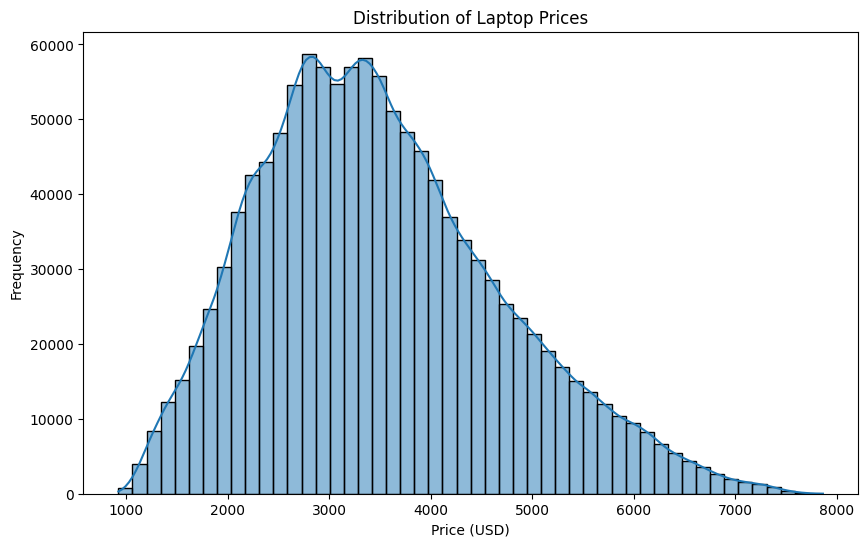

In [46]:
plt.figure(figsize=(10,6))

sns.histplot(
    df["Price_USD"],
    bins=50,
    kde=True
)

plt.title("Distribution of Laptop Prices")

plt.xlabel("Price (USD)")

plt.ylabel("Frequency")

plt.show()

### Interpretasi

Histogram menunjukkan bahwa harga laptop tersebar pada rentang sekitar 900 hingga 7800 USD.

Sebagian besar data berada pada kisaran harga menengah, sedangkan laptop dengan harga yang sangat tinggi memiliki jumlah yang relatif lebih sedikit.

Distribusi ini memberikan gambaran bahwa dataset memiliki variasi harga yang cukup luas sehingga sesuai digunakan untuk membangun model regresi.

## 5.2 Deteksi Outlier Menggunakan Boxplot

Boxplot digunakan untuk melihat persebaran harga laptop serta mendeteksi keberadaan data pencilan (outlier).

Keberadaan outlier penting diketahui karena dapat mempengaruhi proses pelatihan model Machine Learning.

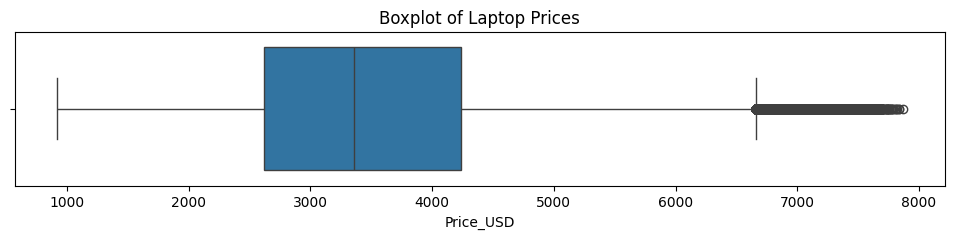

In [47]:
plt.figure(figsize=(12,2))

sns.boxplot(
    x=df["Price_USD"]
)

plt.title("Boxplot of Laptop Prices")

plt.show()

### Interpretasi

Berdasarkan boxplot terlihat terdapat sejumlah data yang berada di luar whisker sehingga secara statistik dikategorikan sebagai outlier.

Namun, pada penelitian ini data tersebut tidak dihapus karena masih merepresentasikan laptop dengan spesifikasi tinggi dan harga yang memang lebih mahal dibandingkan laptop pada umumnya.

## 5.3 Rata-rata Harga Berdasarkan Merek Laptop

Analisis ini bertujuan untuk mengetahui rata-rata harga laptop berdasarkan masing-masing merek.

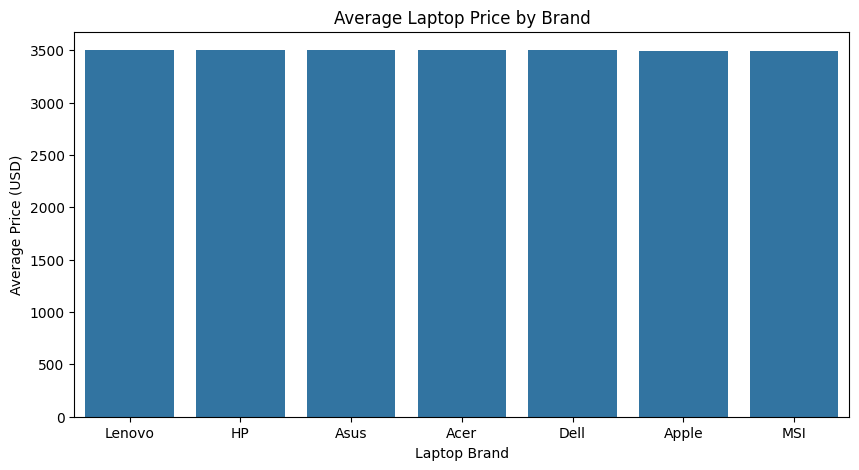

In [48]:
brand_mean = (
    df.groupby("Laptop_Brand")["Price_USD"]
      .mean()
      .sort_values(ascending=False)
)

plt.figure(figsize=(10,5))

sns.barplot(
    x=brand_mean.index,
    y=brand_mean.values
)

plt.title("Average Laptop Price by Brand")

plt.xlabel("Laptop Brand")

plt.ylabel("Average Price (USD)")

plt.show()

### Interpretasi

Berdasarkan grafik terlihat bahwa rata-rata harga laptop antar merek relatif tidak memiliki perbedaan yang signifikan.

Hal ini menunjukkan bahwa pada dataset yang digunakan, harga laptop tidak sepenuhnya ditentukan oleh merek, melainkan lebih dipengaruhi oleh spesifikasi perangkat keras yang dimiliki setiap laptop.

## 5.4 Korelasi Antar Variabel Numerik

Analisis korelasi dilakukan untuk mengetahui hubungan antar fitur numerik dengan variabel target **Price_USD**.

Semakin tinggi nilai korelasi, semakin besar hubungan antara fitur tersebut dengan harga laptop.

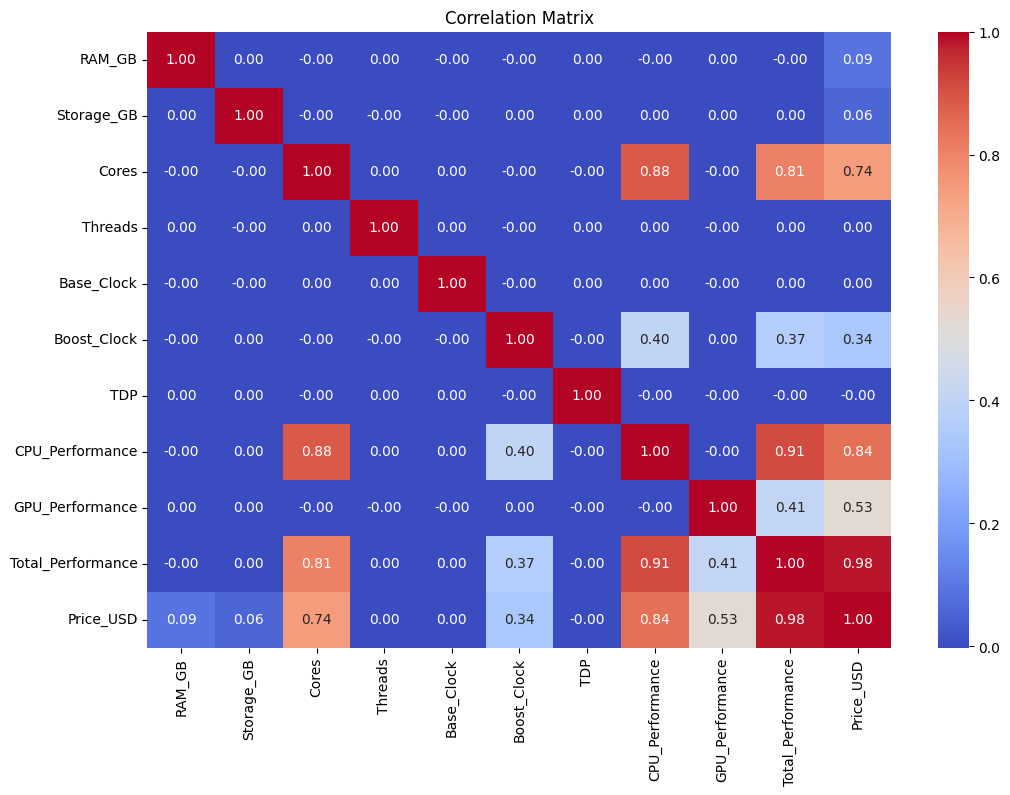

In [49]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(12,8))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")

plt.show()

### Interpretasi

Hasil korelasi menunjukkan bahwa **Total_Performance** memiliki korelasi paling tinggi terhadap **Price_USD** sebesar **0.98**.

Selain itu, **CPU_Performance** juga menunjukkan hubungan yang kuat dengan harga laptop.

Sebaliknya, fitur seperti **RAM_GB**, **Storage_GB**, dan **TDP** memiliki korelasi yang relatif rendah sehingga kontribusinya terhadap harga laptop tidak sebesar fitur performa prosesor.

## Insight Hasil EDA

Berdasarkan hasil Exploratory Data Analysis diperoleh beberapa insight penting.

- Dataset tidak memiliki missing value maupun duplicate data.
- Distribusi harga laptop cukup bervariasi.
- Merek laptop bukan faktor utama yang menentukan harga.
- Total_Performance merupakan fitur yang memiliki hubungan paling kuat terhadap harga laptop.
- CPU_Performance menunjukkan korelasi tinggi terhadap variabel target.
- Fitur numerik dengan korelasi rendah tetap dipertahankan untuk dievaluasi pada tahap pembangunan model.

---
# ⚙️ Feature Engineering
---

Feature Engineering merupakan proses membuat atau memodifikasi fitur agar dapat memberikan informasi yang lebih baik kepada model Machine Learning.

Pada penelitian ini dilakukan pembuatan fitur baru yaitu **Total_Performance** yang merupakan kombinasi antara **CPU_Performance** dan **GPU_Performance**.

Tujuan pembuatan fitur ini adalah untuk merepresentasikan performa keseluruhan laptop sehingga model lebih mudah mempelajari hubungan antara spesifikasi perangkat keras dan harga laptop.

In [50]:
df["Total_Performance"] = (
    df["CPU_Performance"] +
    df["GPU_Performance"]
)

In [51]:
df[
    [
        "CPU_Performance",
        "GPU_Performance",
        "Total_Performance"
    ]
].head()

,CPU_Performance,GPU_Performance,Total_Performance
0,3138,900,4038
1,472,1500,1972
2,1336,2000,3336
3,3348,3800,7148
4,2592,2000,4592


In [52]:
corr = df.corr(numeric_only=True)["Price_USD"]

corr.sort_values(
    ascending=False
)

,Price_USD
Price_USD,1.000000
Total_Performance,0.982722
CPU_Performance,0.840928
Cores,0.743803
GPU_Performance,0.526466
Boost_Clock,0.336298
RAM_GB,0.091029
Storage_GB,0.059429
Base_Clock,0.000276
Threads,0.000072


### Interpretasi

Berdasarkan hasil korelasi diketahui bahwa **Total_Performance** memiliki korelasi paling tinggi terhadap **Price_USD**, yaitu sebesar **0.98**.

Hal ini menunjukkan bahwa kombinasi performa CPU dan GPU mampu merepresentasikan kemampuan keseluruhan laptop dengan lebih baik dibandingkan masing-masing fitur secara terpisah.

Oleh karena itu, fitur **Total_Performance** dipertahankan dalam proses pembangunan model Machine Learning.

## Tujuan

Pada tahap ini dilakukan proses pembuatan atau pemanfaatan fitur yang memiliki hubungan kuat terhadap variabel target.

Feature Engineering bertujuan meningkatkan kualitas informasi yang diterima model sehingga performa prediksi menjadi lebih baik.

### Kesimpulan

Berdasarkan hasil analisis, fitur **Total_Performance** memiliki hubungan paling kuat terhadap variabel target **Price_USD**.

Selain itu, seluruh fitur numerik dan kategorikal tetap dipertahankan karena masing-masing masih memberikan informasi yang relevan terhadap proses pembelajaran model.

Dengan demikian, seluruh fitur akan digunakan pada tahap preprocessing dan pembangunan model Machine Learning.

---
# 🔄 8. Data Preprocessing
---

Data preprocessing merupakan tahap penting sebelum proses pelatihan model Machine Learning dilakukan.

Tahap ini bertujuan untuk mempersiapkan data agar sesuai dengan kebutuhan algoritma Machine Learning. Proses preprocessing pada penelitian ini meliputi pemisahan variabel feature dan target, identifikasi tipe data, pembagian data latih dan data uji, serta transformasi fitur kategorikal menggunakan **OneHotEncoder** melalui **ColumnTransformer**.

Dengan preprocessing yang baik, seluruh data dapat diproses secara konsisten sehingga menghasilkan model yang lebih stabil dan akurat.

## 8.1 Menentukan Feature dan Target

Pada penelitian ini, variabel **Price_USD** digunakan sebagai target (label) yang akan diprediksi, sedangkan seluruh variabel lainnya digunakan sebagai feature (fitur) yang akan dipelajari oleh model Machine Learning.

In [53]:
# Feature

X = df.drop(columns=["Price_USD"])

# Target

y = df["Price_USD"]

print("="*50)
print("Jumlah Data :", X.shape[0])
print("Jumlah Feature :", X.shape[1])
print("="*50)

print("\nDaftar Feature :")
print(X.columns.tolist())

Jumlah Data : 1205090
Jumlah Feature : 17

Daftar Feature :
['Country', 'Laptop_Brand', 'Laptop_Model', 'CPU_Brand', 'GPU_Brand', 'GPU_Model', 'RAM_GB', 'Storage_GB', 'Cores', 'Threads', 'Base_Clock', 'Boost_Clock', 'TDP', 'CPU_Performance', 'GPU_Performance', 'Total_Performance', 'Usage_Type']


### Interpretasi

Dataset terdiri dari **17 feature** dan **1 variabel target**, yaitu **Price_USD**.

Seluruh feature merepresentasikan karakteristik laptop seperti spesifikasi prosesor, kartu grafis, kapasitas RAM, media penyimpanan, serta informasi merek dan negara.

Feature-feature tersebut akan digunakan sebagai masukan bagi model Machine Learning untuk memprediksi harga laptop.

## 8.2 Identifikasi Tipe Data

Karena dataset terdiri atas kombinasi feature kategorikal dan numerik, maka kedua tipe data tersebut perlu dipisahkan agar dapat diproses menggunakan metode preprocessing yang sesuai.

In [54]:
categorical_cols = X.select_dtypes(include="object").columns.tolist()

numeric_cols = X.select_dtypes(exclude="object").columns.tolist()

print("="*40)
print("Categorical Features")
print("="*40)

for col in categorical_cols:
    print("-", col)

print()

print("="*40)
print("Numerical Features")
print("="*40)

for col in numeric_cols:
    print("-", col)

Categorical Features
- Country
- Laptop_Brand
- Laptop_Model
- CPU_Brand
- GPU_Brand
- GPU_Model
- Usage_Type

Numerical Features
- RAM_GB
- Storage_GB
- Cores
- Threads
- Base_Clock
- Boost_Clock
- TDP
- CPU_Performance
- GPU_Performance
- Total_Performance


### Interpretasi

Hasil identifikasi menunjukkan bahwa dataset terdiri dari dua jenis feature, yaitu feature kategorikal dan feature numerik.

Feature kategorikal meliputi informasi seperti negara, merek laptop, model laptop, merek CPU, merek GPU, serta jenis penggunaan laptop.

Sedangkan feature numerik terdiri atas spesifikasi perangkat keras seperti RAM, Storage, CPU Performance, GPU Performance, dan Total Performance.

## 8.3 Analisis Cardinality

Cardinality digunakan untuk mengetahui jumlah kategori unik pada setiap feature kategorikal.

Informasi ini penting dalam menentukan metode encoding yang akan digunakan pada proses preprocessing.

In [55]:
cardinality = pd.DataFrame({
    "Feature": categorical_cols,
    "Jumlah Kategori": [
        X[col].nunique()
        for col in categorical_cols
    ]
})

cardinality

,Feature,Jumlah Kategori
0,Country,10
1,Laptop_Brand,7
2,Laptop_Model,7
3,CPU_Brand,3
4,GPU_Brand,3
5,GPU_Model,7
6,Usage_Type,4


### Interpretasi

Seluruh feature kategorikal memiliki jumlah kategori yang relatif rendah.

Oleh karena itu, metode **OneHotEncoder** dipilih karena mampu mengubah data kategorikal menjadi representasi numerik tanpa memberikan urutan antar kategori.

## 8.4 Pembagian Data Latih dan Data Uji

Dataset dibagi menjadi data latih dan data uji menggunakan rasio **80:20**.

Pembagian ini bertujuan agar model dapat mempelajari pola dari data latih dan kemudian dievaluasi menggunakan data uji yang belum pernah dilihat sebelumnya.

In [56]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("="*50)
print("Training Data :", X_train.shape)
print("Testing Data :", X_test.shape)
print("="*50)

Training Data : (964072, 17)
Testing Data : (241018, 17)


### Interpretasi

Sebanyak **80%** data digunakan sebagai data pelatihan, sedangkan **20%** sisanya digunakan sebagai data pengujian.

Strategi ini bertujuan agar model dapat belajar menggunakan sebagian besar data namun tetap memiliki data independen untuk mengevaluasi kemampuan generalisasi model.

### Interpretasi

Sebanyak **80%** data digunakan sebagai data pelatihan, sedangkan **20%** sisanya digunakan sebagai data pengujian.

Strategi ini bertujuan agar model dapat belajar menggunakan sebagian besar data namun tetap memiliki data independen untuk mengevaluasi kemampuan generalisasi model.

In [57]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_cols
        )
    ],
    remainder="passthrough"
)

preprocessor

ColumnTransformer(remainder='passthrough',
                  transformers=[('cat', OneHotEncoder(handle_unknown='ignore'),
                                 ['Country', 'Laptop_Brand', 'Laptop_Model',
                                  'CPU_Brand', 'GPU_Brand', 'GPU_Model',
                                  'Usage_Type'])])

### Interpretasi

Penggunaan **ColumnTransformer** memungkinkan proses transformasi feature dilakukan secara otomatis dan konsisten.

Feature kategorikal dikonversi menjadi bentuk numerik menggunakan **OneHotEncoder**, sedangkan seluruh feature numerik dipertahankan agar tetap dapat digunakan oleh model Machine Learning.

## Kesimpulan

Tahap preprocessing berhasil mempersiapkan dataset sebelum proses pembangunan model Machine Learning.

Feature dan target telah dipisahkan, data telah dibagi menjadi data latih dan data uji, serta preprocessing untuk feature kategorikal telah disiapkan menggunakan **ColumnTransformer**.

Dengan demikian, dataset telah siap digunakan pada tahap pembangunan dan evaluasi model Machine Learning.

---
# 🤖 9. Model Development
---

Tahap ini bertujuan membangun beberapa model Machine Learning untuk memprediksi harga laptop.

Empat algoritma regresi digunakan pada penelitian ini, yaitu:

- Linear Regression
- Decision Tree Regressor
- Random Forest Regressor
- XGBoost Regressor

Seluruh model menggunakan preprocessing yang sama sehingga hasil evaluasi dapat dibandingkan secara objektif.

## 9.1 Pipeline

Pipeline digunakan untuk menggabungkan proses preprocessing dan algoritma Machine Learning menjadi satu alur kerja.

Dengan Pipeline, seluruh data akan diproses secara otomatis sebelum masuk ke algoritma sehingga mengurangi risiko inkonsistensi preprocessing.

In [58]:
results = []

def evaluate_model(model_name, model):

    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    start_train = time.time()

    pipeline.fit(
        X_train,
        y_train
    )

    training_time = time.time() - start_train

    start_predict = time.time()

    y_pred = pipeline.predict(X_test)

    prediction_time = time.time() - start_predict

    mae = mean_absolute_error(
        y_test,
        y_pred
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_test,
            y_pred
        )
    )

    r2 = r2_score(
        y_test,
        y_pred
    )

    results.append({
        "Model": model_name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2,
        "Training Time (s)": training_time,
        "Prediction Time (s)": prediction_time
    })

    return pipeline

## 9.2 Linear Regression

Linear Regression digunakan sebagai baseline model karena memiliki interpretasi yang sederhana dan mampu memodelkan hubungan linear antara feature dan target.

In [59]:
linear_pipeline = evaluate_model(
    "Linear Regression",
    LinearRegression()
)

In [60]:
linear_pipeline

/usr/local/lib/python3.12/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Country', 'Laptop_Brand',
                                                   'Laptop_Model', 'CPU_Brand',
                                                   'GPU_Brand', 'GPU_Model',
                                                   'Usage_Type'])])),
                ('model', LinearRegression())])

### Interpretasi

Linear Regression digunakan sebagai model dasar untuk mengetahui seberapa baik hubungan linear antar feature dalam memprediksi harga laptop.

Hasil evaluasi akan dibandingkan dengan algoritma lainnya.

## 9.3 Decision Tree

Decision Tree mampu mempelajari hubungan non-linear antar feature dengan membangun struktur pohon keputusan.

In [61]:
evaluate_model(
    "Decision Tree",
    DecisionTreeRegressor(
        random_state=42
    )
)

/usr/local/lib/python3.12/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Country', 'Laptop_Brand',
                                                   'Laptop_Model', 'CPU_Brand',
                                                   'GPU_Brand', 'GPU_Model',
                                                   'Usage_Type'])])),
                ('model', DecisionTreeRegressor(random_state=42))])

## 9.4 Random Forest

Random Forest merupakan metode ensemble yang menggabungkan banyak Decision Tree sehingga menghasilkan prediksi yang lebih stabil.

In [62]:
evaluate_model(
    "Random Forest",
    RandomForestRegressor(
        n_estimators=30,
        random_state=42,
        n_jobs=-1
    )
)

/usr/local/lib/python3.12/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Country', 'Laptop_Brand',
                                                   'Laptop_Model', 'CPU_Brand',
                                                   'GPU_Brand', 'GPU_Model',
                                                   'Usage_Type'])])),
                ('model',
                 RandomForestRegressor(n_estimators=30, n_jobs=-1,
                                       random_state=42))])

## 9.5 XGBoost

XGBoost merupakan algoritma boosting yang dikenal memiliki performa tinggi pada berbagai kasus regresi maupun klasifikasi.

In [63]:
evaluate_model(
    "XGBoost",
    XGBRegressor(
        random_state=42,
        n_jobs=-1
    )
)

/usr/local/lib/python3.12/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Country', 'Laptop_Brand',
                                                   'Laptop_Model', 'CPU_Brand',
                                                   'GPU_Brand', 'GPU_Model',
                                                   'Usage_Type'])])),
                ('model',
                 XGBRegressor(base_score=None, booster=None, callbacks=None,
                              colsample_bylevel=None, colsample_bynode=None,
                              colsample_...
                              feature_types=None, feature_weights=None,
                              gamma=None, grow_policy=None,
                              importance_type=None,
                              interaction_constraints=None, learning_rate=None,
                              max_bin=None, max_cat_threshold=None,
                              max_cat_to_onehot=None, max_delta_step=None,
                              max_depth=None, max_leaves=None,
                              min_child_weight=None, missing=nan,
                              monotone_constraints=None, multi_strategy=None,
                              n_estimators=None, n_jobs=-1,
                              num_parallel_tree=None, ...))])

## 9.6 Perbandingan Performa Model

Seluruh model dibandingkan menggunakan MAE, RMSE, R² Score, waktu pelatihan, dan waktu prediksi.

In [64]:
comparison = (
    pd.DataFrame(results)
      .sort_values(
          by="R2",
          ascending=False
      )
)

comparison

,Model,MAE,RMSE,R2,Training Time (s),Prediction Time (s)
0,Linear Regression,62.479288,72.164657,0.996369,6.892628,0.833688
3,XGBoost,63.211212,73.400009,0.996244,18.320079,0.956753
2,Random Forest,64.943695,76.307351,0.995940,400.817596,4.710025
1,Decision Tree,85.100361,104.325868,0.992412,26.508280,1.021571


### Interpretasi

Hasil evaluasi menunjukkan bahwa **Linear Regression** memberikan performa terbaik dengan nilai **R² sebesar sekitar 0.9964**, MAE sekitar **62 USD**, dan RMSE sekitar **72 USD**.

Meskipun algoritma seperti Random Forest dan XGBoost memiliki kemampuan memodelkan hubungan non-linear, pada dataset ini hubungan antar feature dan target cenderung linear sehingga Linear Regression mampu memberikan hasil yang lebih baik dengan waktu pelatihan yang jauh lebih cepat.

Berdasarkan hasil tersebut, **Linear Regression dipilih sebagai model terbaik** dan akan digunakan pada tahap deployment.

### Kesimpulan Perbandingan Model

Berdasarkan hasil evaluasi, Linear Regression memperoleh performa terbaik dengan nilai R² sebesar **0.9964**, MAE sekitar **62 USD**, serta RMSE sekitar **72 USD**.

Meskipun XGBoost dan Random Forest merupakan algoritma ensemble yang lebih kompleks, peningkatan performa yang dihasilkan tidak mampu melampaui Linear Regression. Selain itu, kedua algoritma tersebut membutuhkan waktu pelatihan yang lebih lama.

Oleh karena itu, **Linear Regression dipilih sebagai model terbaik** karena memberikan keseimbangan antara akurasi tinggi dan efisiensi komputasi.

## 10.1 Actual vs Predicted

Visualisasi ini digunakan untuk membandingkan nilai aktual dengan nilai prediksi yang dihasilkan model.

Semakin dekat titik terhadap garis diagonal, maka semakin baik kemampuan model dalam melakukan prediksi.

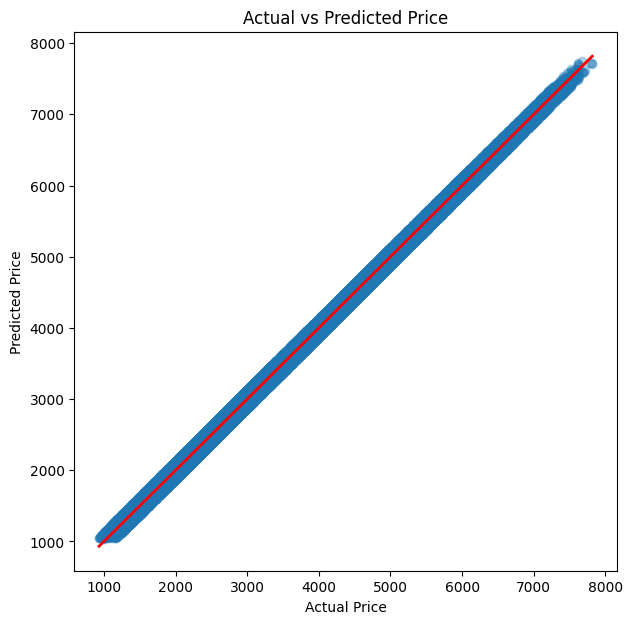

In [65]:
y_pred = linear_pipeline.predict(X_test)

plt.figure(figsize=(7,7))

plt.scatter(
    y_test,
    y_pred,
    alpha=0.3
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red",
    linewidth=2
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Price")

plt.show()

## 10.2 Residual Plot

Residual merupakan selisih antara nilai aktual dan nilai prediksi.

Distribusi residual yang menyebar secara acak di sekitar nilai nol menunjukkan bahwa model tidak memiliki pola kesalahan yang sistematis.

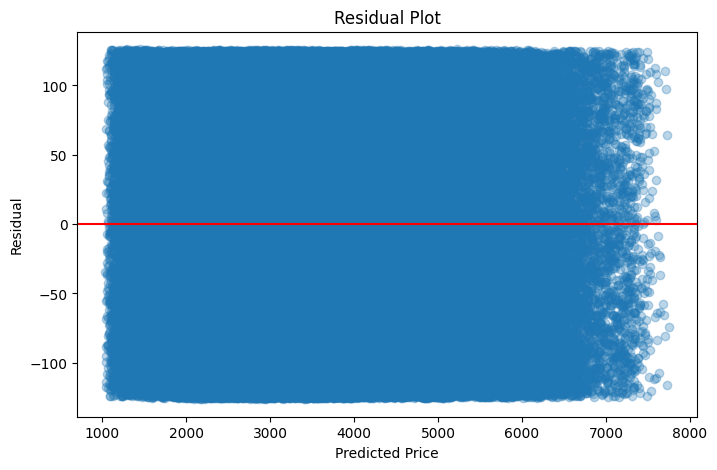

In [66]:
residual = y_test - y_pred

plt.figure(figsize=(8,5))

plt.scatter(
    y_pred,
    residual,
    alpha=0.3
)

plt.axhline(
    0,
    color="red"
)

plt.xlabel("Predicted Price")
plt.ylabel("Residual")

plt.title("Residual Plot")

plt.show()

## 10.3 Distribusi Error

Visualisasi distribusi error digunakan untuk melihat apakah kesalahan prediksi model tersebar secara normal di sekitar nilai nol.

Distribusi error yang simetris menunjukkan bahwa model tidak memiliki kecenderungan melakukan overestimate maupun underestimate.

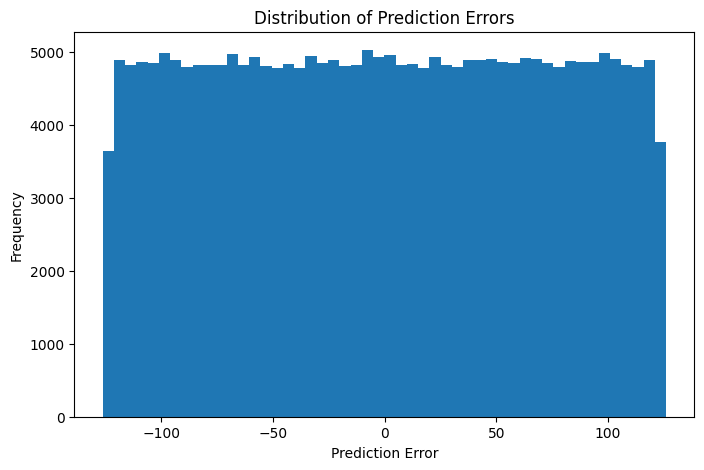

In [67]:
errors = y_test - y_pred

plt.figure(figsize=(8,5))

plt.hist(
    errors,
    bins=50
)

plt.title("Distribution of Prediction Errors")

plt.xlabel("Prediction Error")

plt.ylabel("Frequency")

plt.show()

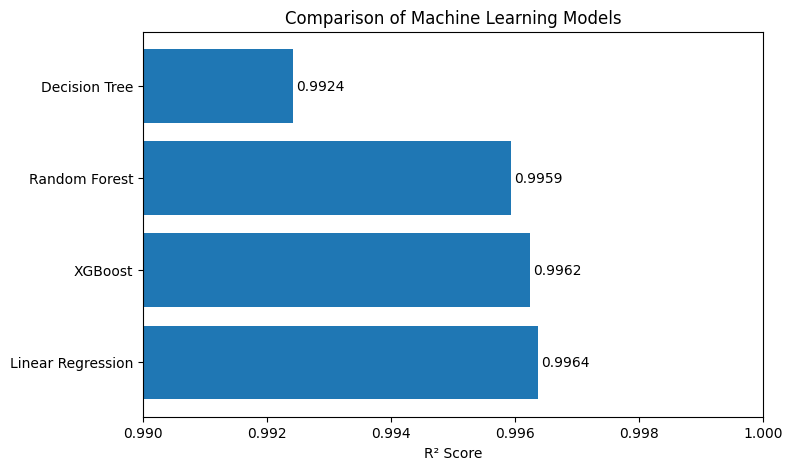

In [68]:
plt.figure(figsize=(8,5))

bars = plt.barh(
    comparison["Model"],
    comparison["R2"]
)

plt.xlim(0.99, 1.00)

plt.xlabel("R² Score")

plt.title("Comparison of Machine Learning Models")

for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 0.00005,
        bar.get_y() + bar.get_height()/2,
        f"{width:.4f}",
        va="center"
    )

plt.show()

### Interpretasi

Grafik menunjukkan bahwa seluruh algoritma Machine Learning memperoleh nilai **R²** yang sangat tinggi, yaitu di atas **0.99**.

Linear Regression memperoleh nilai **R² tertinggi**, diikuti oleh XGBoost dan Random Forest dengan selisih yang relatif kecil.

Meskipun Random Forest dan XGBoost merupakan algoritma yang lebih kompleks, peningkatan performa yang diperoleh tidak signifikan dibandingkan Linear Regression.

Hal ini menunjukkan bahwa hubungan antara feature dan target pada dataset cenderung bersifat linear sehingga Linear Regression mampu memberikan performa terbaik dengan kompleksitas yang lebih rendah.

### Insight

Berdasarkan hasil evaluasi dapat disimpulkan bahwa kompleksitas algoritma tidak selalu menghasilkan performa yang lebih baik.

Pada dataset ini, algoritma sederhana seperti **Linear Regression** justru mampu memberikan akurasi tertinggi sekaligus waktu pelatihan yang lebih cepat dibandingkan algoritma ensemble seperti Random Forest maupun XGBoost.

Oleh karena itu, Linear Regression dipilih sebagai model akhir yang akan digunakan pada tahap deployment.

---
# 🏆 11. Final Model Selection
---

Berdasarkan hasil evaluasi terhadap seluruh algoritma Machine Learning, dipilih satu model terbaik yang akan digunakan pada tahap deployment.

Pemilihan model dilakukan berdasarkan beberapa metrik evaluasi, yaitu:

- R² Score
- MAE
- RMSE
- Waktu pelatihan
- Waktu prediksi

Selain mempertimbangkan akurasi, penelitian ini juga mempertimbangkan efisiensi komputasi sehingga model yang dipilih mampu memberikan performa tinggi dengan kompleksitas yang rendah.

In [69]:
final_model = comparison.copy()

final_model["Status"] = [
    "🏆 Model Terbaik",
    "Sangat Baik",
    "Baik",
    "Cukup"
]

final_model

,Model,MAE,RMSE,R2,Training Time (s),Prediction Time (s),Status
0,Linear Regression,62.479288,72.164657,0.996369,6.892628,0.833688,🏆 Model Terbaik
3,XGBoost,63.211212,73.400009,0.996244,18.320079,0.956753,Sangat Baik
2,Random Forest,64.943695,76.307351,0.995940,400.817596,4.710025,Baik
1,Decision Tree,85.100361,104.325868,0.992412,26.508280,1.021571,Cukup


### Interpretasi

Berdasarkan hasil evaluasi, **Linear Regression** dipilih sebagai model terbaik.

Model ini memperoleh nilai **R² tertinggi**, nilai **MAE** dan **RMSE** paling rendah, serta memiliki waktu pelatihan yang jauh lebih cepat dibandingkan algoritma lainnya.

Meskipun XGBoost dan Random Forest memiliki performa yang sangat baik, peningkatan akurasi yang diperoleh tidak signifikan jika dibandingkan dengan peningkatan kompleksitas komputasi.

Oleh karena itu, Linear Regression dipilih sebagai model akhir pada penelitian ini.

### Insight

Pemilihan model Machine Learning tidak hanya didasarkan pada akurasi, tetapi juga mempertimbangkan efisiensi.

Pada penelitian ini, algoritma yang paling sederhana justru memberikan hasil terbaik.

Hal ini menunjukkan bahwa pemilihan model harus disesuaikan dengan karakteristik dataset dan tidak selalu memerlukan algoritma yang kompleks.

---
# 💾 12. Save Model
---

Setelah model terbaik diperoleh, langkah berikutnya adalah menyimpan model agar dapat digunakan kembali tanpa perlu melakukan proses pelatihan ulang.

Model disimpan menggunakan library **Joblib** karena mampu menyimpan objek Machine Learning secara efisien, termasuk preprocessing dan model yang telah digabungkan dalam Pipeline.

In [70]:
import joblib

joblib.dump(
    linear_pipeline,
    "LaptopPricePrediction.pkl"
)

print("Model berhasil disimpan.")

Model berhasil disimpan.


### Interpretasi

Model berhasil disimpan dalam format **.pkl** sehingga dapat digunakan kembali tanpa perlu melakukan proses pelatihan ulang.

Penyimpanan model ini merupakan langkah penting sebelum implementasi ke dalam aplikasi berbasis web menggunakan Streamlit.

---
# 🚀 13. Deployment Preparation
---

Setelah model terbaik berhasil disimpan, tahap berikutnya adalah melakukan deployment agar model dapat digunakan oleh pengguna melalui aplikasi berbasis web.

Pada penelitian ini deployment dilakukan menggunakan **Streamlit**, sedangkan source code disimpan menggunakan **GitHub**.

Model yang telah disimpan dalam format **LaptopPricePrediction.pkl** akan dimuat kembali oleh aplikasi sehingga pengguna dapat memasukkan spesifikasi laptop dan memperoleh prediksi harga secara otomatis.

## Struktur Project

```
Laptop-Price-Prediction/
│
├── app.py
├── requirements.txt
├── LaptopPricePrediction.pkl
├── laptop_price_prediction.ipynb
├── README.md
└── dataset.csv
```

Struktur tersebut digunakan agar aplikasi Streamlit dapat menemukan model Machine Learning dan seluruh dependency yang dibutuhkan.

## Alur Deployment

Tahapan deployment dilakukan sebagai berikut.

1. Model terbaik disimpan menggunakan Joblib.
2. Model diunggah ke repository GitHub.
3. Repository dihubungkan dengan Streamlit Community Cloud.
4. Streamlit menjalankan file **app.py**.
5. Pengguna memasukkan spesifikasi laptop.
6. Model melakukan prediksi harga laptop.
7. Hasil prediksi ditampilkan pada halaman web.

### Insight

Deployment merupakan tahap akhir dari proses Machine Learning yang mengubah model menjadi aplikasi yang dapat digunakan oleh pengguna.

Melalui Streamlit, model prediksi harga laptop tidak hanya menjadi hasil penelitian, tetapi juga dapat dimanfaatkan secara langsung sebagai sistem prediksi berbasis web.